# Data Prep

* View data_prep folder and pipeline file for detailed info
* Parameter to change on new Data: constants.py with cols and paths,
also fail_on_duplcate must be set to true if duplicated values are viewed to be an error (timestamps are always errors).

In [1]:
print("test")

test


In [2]:
from pathlib import Path
import sys

# Ensure the project src/ directory is importable from the notebook.
_cwd = Path.cwd().resolve()
PROJECT_ROOT = next(
    p for p in [_cwd, *_cwd.parents] if (p / "src" / "timeseries_forecast").exists()
)
SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from timeseries_forecast.data_prep.raw_data import read_raw_metals_data
from timeseries_forecast.data_prep.pipeline import run_data_pipeline
from timeseries_forecast.data_prep.data_merge import merge_all_raw_data
from timeseries_forecast.data_prep.constants import RawMetalsColumn
import pandas as pd
import numpy as np

# from timeseries_forecast.feature import autoregressive_features
from timeseries_forecast.eval.eval import evaluate, evaluate_predictions
# from timeseries_forecast.feature.custom_features import add_log_ret_features
# from timeseries_forecast.feature import engineer_features
# from timeseries_forecast.config.feature_config import FeatureConfig
# from timeseries_forecast.data_prep.data_resample import resample_dataframe_with_aggregations

from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR, LinearSVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.neighbors import KNeighborsRegressor


ModuleNotFoundError: No module named 'lightgbm'

In [ ]:
alu_df = read_raw_metals_data("aluminium")
alu_df.Date

0      2024-08-29
1      2024-08-28
2      2024-08-27
3      2024-08-26
4      2024-08-23
          ...    
2730   2014-01-07
2731   2014-01-06
2732   2014-01-03
2733   2014-01-02
2734   2014-01-01
Name: Date, Length: 2735, dtype: datetime64[us]

## Cleaning for all metals with same parameters

### Aluminium

In [ ]:
aluminium_df_cleaned = run_data_pipeline(
    read_raw_metals_data("aluminium"),
    timestamp_column=RawMetalsColumn.OPEN_TIME,
    data_freq="D",
    split_train_end="2019-12-31",
    split_val_end="2021-12-31",
    zero_value_ignore_cols=[RawMetalsColumn.PCT_CHANGE],
    zero_as_nan_cols=[RawMetalsColumn.VOLUME],
).rename(columns={RawMetalsColumn.PRICE: "Close"}).drop(columns=[RawMetalsColumn.PCT_CHANGE])
aluminium_df_cleaned


Duplikat-Check
OK: Keine doppelten Zeitstempel im Index
WARN: 4 Zeilen sind doppelt (identischer Inhalt)
  Beispiele (erste 5 Timestamps):
DatetimeIndex(['2020-09-29', '2020-09-30', '2024-07-30', '2024-07-31'], dtype='datetime64[us]', name='RawMetalsColumn.OPEN_TIME', freq=None)

Fehlende Werte Check
WARN: Es gibt 1159 Lücken in der Zeitreihe (erwartete Frequenz: D).

NaN-Check
WARN: 15 NaN-Werte insgesamt gefunden:
  Vol.: 15 (0.55%)

0-Werte Check
WARN: 32 0-Werte insgesamt gefunden:
  Vol.: 32 (1.17%)

Data Cleaning – Interpolation von Missing Values und Nullwerten

  Vollständiger Zeitindex: 3,894 Einträge
  Aktueller DataFrame:    2,735 Zeilen
  Zu ergänzende Einträge: 1,159
    RawMetalsColumn.VOLUME: 32 Nullwerte -> NaN ersetzt

  Interpoliere 6 numerische Spalten:
    Price: 1159 -> 0 NaN
    Open: 1159 -> 0 NaN
    High: 1159 -> 0 NaN
    Low: 1159 -> 0 NaN
    Vol.: 1206 -> 0 NaN
    Change %: 1159 -> 0 NaN

  Shape vorher:  (2735, 6)
  Shape nachher: (3894, 6)
OK: Interpola

,Close,Open,High,Low,Vol.,Mode
2014-01-01,110.10,110.000000,110.700000,109.900000,450.000000,Train
2014-01-02,111.20,110.550000,112.200000,110.450000,4720.000000,Train
2014-01-03,109.20,110.900000,111.100000,109.050000,4520.000000,Train
2014-01-04,109.35,110.433333,110.650000,108.733333,4333.333333,Train
2014-01-05,109.50,109.966667,110.200000,108.416667,4146.666667,Train
...,...,...,...,...,...,...
2024-08-25,229.60,229.450000,232.433333,227.483333,1236.666667,Test
2024-08-26,229.50,230.850000,233.500000,228.850000,510.000000,Test
2024-08-27,231.55,229.000000,233.000000,228.200000,60.000000,Test
2024-08-28,232.05,233.400000,233.400000,231.400000,35.000000,Test


In [ ]:
# alu_df_cleaned.loc["25-08-2024"]

### Copper

In [ ]:
copper_df_cleaned = run_data_pipeline(
    read_raw_metals_data("copper"),
    timestamp_column=RawMetalsColumn.OPEN_TIME,
    data_freq="D",
    split_train_end="2019-12-31",
    split_val_end="2021-12-31",
    zero_value_ignore_cols=[RawMetalsColumn.PCT_CHANGE],
    zero_as_nan_cols=[RawMetalsColumn.VOLUME],
).rename(columns={RawMetalsColumn.PRICE: "Close"}).drop(columns=[RawMetalsColumn.PCT_CHANGE])


Duplikat-Check
OK: Keine doppelten Zeitstempel im Index
OK: Keine identischen Zeilenduplikate gefunden

Fehlende Werte Check
WARN: Es gibt 1136 Lücken in der Zeitreihe (erwartete Frequenz: D).

NaN-Check
WARN: 20 NaN-Werte insgesamt gefunden:
  Vol.: 20 (0.73%)

0-Werte Check
WARN: 5 0-Werte insgesamt gefunden:
  Vol.: 5 (0.18%)

Data Cleaning – Interpolation von Missing Values und Nullwerten

  Vollständiger Zeitindex: 3,894 Einträge
  Aktueller DataFrame:    2,758 Zeilen
  Zu ergänzende Einträge: 1,136
    RawMetalsColumn.VOLUME: 5 Nullwerte -> NaN ersetzt

  Interpoliere 6 numerische Spalten:
    Price: 1136 -> 0 NaN
    Open: 1136 -> 0 NaN
    High: 1136 -> 0 NaN
    Low: 1136 -> 0 NaN
    Vol.: 1161 -> 0 NaN
    Change %: 1136 -> 0 NaN

  Shape vorher:  (2758, 6)
  Shape nachher: (3894, 6)
OK: Interpolation abgeschlossen!

Duplikat-Check
OK: Keine doppelten Zeitstempel im Index
OK: Keine identischen Zeilenduplikate gefunden

Fehlende Werte Check
OK: Keine Lücken in der Zeitreihe 

### gold

In [ ]:
gold_df_cleaned = run_data_pipeline(
    read_raw_metals_data("gold"),
    timestamp_column=RawMetalsColumn.OPEN_TIME,
    data_freq="D",
    split_train_end="2019-12-31",
    split_val_end="2021-12-31",
    zero_value_ignore_cols=[RawMetalsColumn.PCT_CHANGE],
    zero_as_nan_cols=[RawMetalsColumn.VOLUME],
).rename(columns={RawMetalsColumn.PRICE: "Close"}).drop(columns=[RawMetalsColumn.PCT_CHANGE])


Duplikat-Check
OK: Keine doppelten Zeitstempel im Index
OK: Keine identischen Zeilenduplikate gefunden

Fehlende Werte Check
WARN: Es gibt 1135 Lücken in der Zeitreihe (erwartete Frequenz: D).

NaN-Check
WARN: 22 NaN-Werte insgesamt gefunden:
  Vol.: 22 (0.80%)

0-Werte Check
WARN: 7 0-Werte insgesamt gefunden:
  Vol.: 7 (0.25%)

Data Cleaning – Interpolation von Missing Values und Nullwerten

  Vollständiger Zeitindex: 3,895 Einträge
  Aktueller DataFrame:    2,760 Zeilen
  Zu ergänzende Einträge: 1,135
    RawMetalsColumn.VOLUME: 7 Nullwerte -> NaN ersetzt

  Interpoliere 6 numerische Spalten:
    Price: 1135 -> 0 NaN
    Open: 1135 -> 0 NaN
    High: 1135 -> 0 NaN
    Low: 1135 -> 0 NaN
    Vol.: 1164 -> 0 NaN
    Change %: 1135 -> 0 NaN

  Shape vorher:  (2760, 6)
  Shape nachher: (3895, 6)
OK: Interpolation abgeschlossen!

Duplikat-Check
OK: Keine doppelten Zeitstempel im Index
OK: Keine identischen Zeilenduplikate gefunden

Fehlende Werte Check
OK: Keine Lücken in der Zeitreihe 

### lead

In [ ]:
lead_df_cleaned = run_data_pipeline(
    read_raw_metals_data("lead"),
    timestamp_column=RawMetalsColumn.OPEN_TIME,
    data_freq="D",
    split_train_end="2019-12-31",
    split_val_end="2021-12-31",
    zero_value_ignore_cols=[RawMetalsColumn.PCT_CHANGE],
    zero_as_nan_cols=[RawMetalsColumn.VOLUME],
    fail_on_row_duplicates=False,
).rename(columns={RawMetalsColumn.PRICE: "Close"}).drop(columns=[RawMetalsColumn.PCT_CHANGE])


Duplikat-Check
OK: Keine doppelten Zeitstempel im Index
WARN: 6 Zeilen sind doppelt (identischer Inhalt)
  Beispiele (erste 5 Timestamps):
DatetimeIndex(['2023-03-29', '2023-03-30', '2023-07-27', '2023-07-28',
               '2024-02-26'],
              dtype='datetime64[us]', name='RawMetalsColumn.OPEN_TIME', freq=None)

Fehlende Werte Check
WARN: Es gibt 1137 Lücken in der Zeitreihe (erwartete Frequenz: D).

NaN-Check
WARN: 31 NaN-Werte insgesamt gefunden:
  Vol.: 31 (1.12%)

0-Werte Check
WARN: 45 0-Werte insgesamt gefunden:
  Vol.: 45 (1.63%)

Data Cleaning – Interpolation von Missing Values und Nullwerten

  Vollständiger Zeitindex: 3,894 Einträge
  Aktueller DataFrame:    2,757 Zeilen
  Zu ergänzende Einträge: 1,137
    RawMetalsColumn.VOLUME: 45 Nullwerte -> NaN ersetzt

  Interpoliere 6 numerische Spalten:
    Price: 1137 -> 0 NaN
    Open: 1137 -> 0 NaN
    High: 1137 -> 0 NaN
    Low: 1137 -> 0 NaN
    Vol.: 1213 -> 0 NaN
    Change %: 1137 -> 0 NaN

  Shape vorher:  (2757, 

### nickel

In [ ]:
nickel_df_cleaned = run_data_pipeline(
    read_raw_metals_data("nickel"),
    timestamp_column=RawMetalsColumn.OPEN_TIME,
    data_freq="D",
    split_train_end="2019-12-31",
    split_val_end="2021-12-31",
    zero_value_ignore_cols=[RawMetalsColumn.PCT_CHANGE],
    zero_as_nan_cols=[
        RawMetalsColumn.VOLUME,
        RawMetalsColumn.OPEN,
        RawMetalsColumn.HIGH,
        RawMetalsColumn.LOW,
    ],
).rename(columns={RawMetalsColumn.PRICE: "Close"}).drop(columns=[RawMetalsColumn.PCT_CHANGE])
nickel_df_cleaned


Duplikat-Check
OK: Keine doppelten Zeitstempel im Index
WARN: 21 Zeilen sind doppelt (identischer Inhalt)
  Beispiele (erste 5 Timestamps):
DatetimeIndex(['2022-05-27', '2022-05-30', '2022-05-31', '2022-06-02',
               '2022-06-03'],
              dtype='datetime64[us]', name='RawMetalsColumn.OPEN_TIME', freq=None)

Fehlende Werte Check
WARN: Es gibt 1139 Lücken in der Zeitreihe (erwartete Frequenz: D).

NaN-Check
WARN: 580 NaN-Werte insgesamt gefunden:
  Vol.: 580 (21.05%)

0-Werte Check
WARN: 40 0-Werte insgesamt gefunden:
  Open: 1 (0.04%)
  High: 1 (0.04%)
  Low: 1 (0.04%)
  Vol.: 37 (1.34%)

Data Cleaning – Interpolation von Missing Values und Nullwerten

  Vollständiger Zeitindex: 3,894 Einträge
  Aktueller DataFrame:    2,755 Zeilen
  Zu ergänzende Einträge: 1,139
    RawMetalsColumn.VOLUME: 37 Nullwerte -> NaN ersetzt
    RawMetalsColumn.OPEN: 1 Nullwerte -> NaN ersetzt
    RawMetalsColumn.HIGH: 1 Nullwerte -> NaN ersetzt
    RawMetalsColumn.LOW: 1 Nullwerte -> NaN erse

,Close,Open,High,Low,Vol.,Mode
2014-01-01,866.100000,867.000000,869.900000,863.000000,2430.000000,Train
2014-01-02,875.200000,869.900000,880.500000,862.600000,20390.000000,Train
2014-01-03,865.100000,873.100000,875.000000,863.500000,13910.000000,Train
2014-01-04,865.100000,865.100000,865.100000,865.100000,16163.333333,Train
2014-01-05,858.100000,866.300000,867.200000,856.100000,18416.666667,Train
...,...,...,...,...,...,...
2024-08-25,1415.833333,1415.833333,1415.833333,1415.833333,20.000000,Test
2024-08-26,1420.400000,1420.400000,1420.400000,1420.400000,20.000000,Test
2024-08-27,1420.400000,1420.400000,1420.400000,1420.400000,20.000000,Test
2024-08-28,1438.000000,1438.000000,1438.000000,1438.000000,20.000000,Test


### silver

In [ ]:
silver_df_cleaned = run_data_pipeline(
    read_raw_metals_data("silver"),
    timestamp_column=RawMetalsColumn.OPEN_TIME,
    data_freq="D",
    split_train_end="2019-12-31",
    split_val_end="2021-12-31",
    zero_value_ignore_cols=[RawMetalsColumn.PCT_CHANGE],
    zero_as_nan_cols=[
        RawMetalsColumn.VOLUME,
        RawMetalsColumn.OPEN,
        RawMetalsColumn.HIGH,
        RawMetalsColumn.LOW,
    ],
).rename(columns={RawMetalsColumn.PRICE: "Close"}).drop(columns=[RawMetalsColumn.PCT_CHANGE])


Duplikat-Check
OK: Keine doppelten Zeitstempel im Index
OK: Keine identischen Zeilenduplikate gefunden

Fehlende Werte Check
WARN: Es gibt 1136 Lücken in der Zeitreihe (erwartete Frequenz: D).

NaN-Check
WARN: 18 NaN-Werte insgesamt gefunden:
  Vol.: 18 (0.65%)

0-Werte Check
WARN: 5 0-Werte insgesamt gefunden:
  Vol.: 5 (0.18%)

Data Cleaning – Interpolation von Missing Values und Nullwerten

  Vollständiger Zeitindex: 3,895 Einträge
  Aktueller DataFrame:    2,759 Zeilen
  Zu ergänzende Einträge: 1,136
    RawMetalsColumn.VOLUME: 5 Nullwerte -> NaN ersetzt

  Interpoliere 6 numerische Spalten:
    Price: 1136 -> 0 NaN
    Open: 1136 -> 0 NaN
    High: 1136 -> 0 NaN
    Low: 1136 -> 0 NaN
    Vol.: 1159 -> 0 NaN
    Change %: 1136 -> 0 NaN

  Shape vorher:  (2759, 6)
  Shape nachher: (3895, 6)
OK: Interpolation abgeschlossen!

Duplikat-Check
OK: Keine doppelten Zeitstempel im Index
OK: Keine identischen Zeilenduplikate gefunden

Fehlende Werte Check
OK: Keine Lücken in der Zeitreihe 

### zinc

In [ ]:
zinc_df_cleaned = run_data_pipeline(
    read_raw_metals_data("zinc"),
    timestamp_column=RawMetalsColumn.OPEN_TIME,
    data_freq="D",
    split_train_end="2019-12-31",
    split_val_end="2021-12-31",
    zero_value_ignore_cols=[RawMetalsColumn.PCT_CHANGE],
    zero_as_nan_cols=[RawMetalsColumn.VOLUME],
).rename(columns={RawMetalsColumn.PRICE: "Close"}).drop(columns=[RawMetalsColumn.PCT_CHANGE])


Duplikat-Check
OK: Keine doppelten Zeitstempel im Index
OK: Keine identischen Zeilenduplikate gefunden

Fehlende Werte Check
WARN: Es gibt 1137 Lücken in der Zeitreihe (erwartete Frequenz: D).

NaN-Check
WARN: 19 NaN-Werte insgesamt gefunden:
  Vol.: 19 (0.69%)

0-Werte Check
WARN: 13 0-Werte insgesamt gefunden:
  Vol.: 13 (0.47%)

Data Cleaning – Interpolation von Missing Values und Nullwerten

  Vollständiger Zeitindex: 3,895 Einträge
  Aktueller DataFrame:    2,758 Zeilen
  Zu ergänzende Einträge: 1,137
    RawMetalsColumn.VOLUME: 13 Nullwerte -> NaN ersetzt

  Interpoliere 6 numerische Spalten:
    Price: 1137 -> 0 NaN
    Open: 1137 -> 0 NaN
    High: 1137 -> 0 NaN
    Low: 1137 -> 0 NaN
    Vol.: 1169 -> 0 NaN
    Change %: 1137 -> 0 NaN

  Shape vorher:  (2758, 6)
  Shape nachher: (3895, 6)
OK: Interpolation abgeschlossen!

Duplikat-Check
OK: Keine doppelten Zeitstempel im Index
OK: Keine identischen Zeilenduplikate gefunden

Fehlende Werte Check
OK: Keine Lücken in der Zeitrei

## SP 500

In [ ]:
sp500_df_cleaned = run_data_pipeline(
    read_raw_metals_data("sp500"),
    timestamp_column=RawMetalsColumn.OPEN_TIME,
    data_freq="D",
    split_train_end="2019-12-31",
    split_val_end="2021-12-31",
    zero_value_ignore_cols=[
        RawMetalsColumn.PCT_CHANGE,
        RawMetalsColumn.VOLUME],
    zero_as_nan_cols=[
        RawMetalsColumn.OPEN,
        RawMetalsColumn.HIGH,
        RawMetalsColumn.LOW,
    ],
).rename(columns={RawMetalsColumn.PRICE: "Close"}).drop(columns=[RawMetalsColumn.PCT_CHANGE]).drop(columns=[RawMetalsColumn.VOLUME])


Duplikat-Check
OK: Keine doppelten Zeitstempel im Index
OK: Keine identischen Zeilenduplikate gefunden

Fehlende Werte Check
WARN: Es gibt 1602 Lücken in der Zeitreihe (erwartete Frequenz: D).

NaN-Check
WARN: 3540 NaN-Werte insgesamt gefunden:
  Vol.: 3540 (99.97%)

0-Werte Check
OK: Keine 0-Werte gefunden!

Data Cleaning – Interpolation von Missing Values und Nullwerten

  Vollständiger Zeitindex: 5,143 Einträge
  Aktueller DataFrame:    3,541 Zeilen
  Zu ergänzende Einträge: 1,602

  Interpoliere 6 numerische Spalten:
    Price: 1602 -> 0 NaN
    Open: 1602 -> 0 NaN
    High: 1602 -> 0 NaN
    Low: 1602 -> 0 NaN
    Vol.: 5142 -> 0 NaN
    Change %: 1602 -> 0 NaN

  Shape vorher:  (3541, 6)
  Shape nachher: (5143, 6)
OK: Interpolation abgeschlossen!

Duplikat-Check
OK: Keine doppelten Zeitstempel im Index
OK: Keine identischen Zeilenduplikate gefunden

Fehlende Werte Check
OK: Keine Lücken in der Zeitreihe gefunden (Frequenz: D).

NaN-Check
OK: Keine NaN-Werte gefunden!

0-Werte Ch

## Merge

In [ ]:
merged_df = merge_all_raw_data(
    aluminium_df_cleaned=aluminium_df_cleaned,
    copper_df_cleaned=copper_df_cleaned,
    gold_df_cleaned=gold_df_cleaned,
    lead_df_cleaned=lead_df_cleaned,
    nickel_df_cleaned=nickel_df_cleaned,
    silver_df_cleaned=silver_df_cleaned,
    zinc_df_cleaned=zinc_df_cleaned,
    sp500_df_cleaned=sp500_df_cleaned,
)

In [ ]:
df = merged_df.copy()
df.columns

Index(['ALU_Close', 'ALU_Open', 'ALU_High', 'ALU_Low', 'ALU_Vol.', 'ALU_Mode',
       'COPPER_Close', 'COPPER_Open', 'COPPER_High', 'COPPER_Low',
       'COPPER_Vol.', 'COPPER_Mode', 'GOLD_Close', 'GOLD_Open', 'GOLD_High',
       'GOLD_Low', 'GOLD_Vol.', 'GOLD_Mode', 'LEAD_Close', 'LEAD_Open',
       'LEAD_High', 'LEAD_Low', 'LEAD_Vol.', 'LEAD_Mode', 'NICKEL_Close',
       'NICKEL_Open', 'NICKEL_High', 'NICKEL_Low', 'NICKEL_Vol.',
       'NICKEL_Mode', 'SILVER_Close', 'SILVER_Open', 'SILVER_High',
       'SILVER_Low', 'SILVER_Vol.', 'SILVER_Mode', 'ZINC_Close', 'ZINC_Open',
       'ZINC_High', 'ZINC_Low', 'ZINC_Vol.', 'ZINC_Mode', 'SP500_Close',
       'SP500_Open', 'SP500_High', 'SP500_Low', 'SP500_Mode'],
      dtype='str')

In [ ]:
# # Test the function
# frequency_resample = '1h'

# resampled = resample_dataframe_with_aggregations(df, frequency_resample)
# print(f"Original shape: {df.shape}")
# print(f"Resampled {frequency_resample} shape: {resampled.shape}")
# print(f"\nFirst few rows of resampled data:")
# print(resampled.head())

In [ ]:
# df = resampled.copy()

In [ ]:
models = [
    # RandomForestRegressor(random_state=42),
    # DecisionTreeRegressor(random_state=42),
    Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVR(C=10.0, epsilon=0.001, gamma="scale"))
    ]),
    Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),
    LGBMRegressor(
        random_state=42,
        n_estimators=1200,
        learning_rate=0.02,
        num_leaves=63,
        min_child_samples=10,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.0,
        reg_lambda=0.5,
        objective="regression",
        n_jobs=-1,
        boost_from_average=False,
    ),
    XGBRegressor(
        random_state=42,
        n_estimators=1200,
        learning_rate=0.02,
        max_depth=6,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.1,
        reg_lambda=1.0,
        objective="reg:squarederror",
        n_jobs=-1,
    ),
    Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsRegressor(n_neighbors=15, weights="distance"))
    ])
]


In [ ]:
# fügt eine type spalte als label (target) hinzu
# macht die timestamp spalte explizit, damit man daraus infos extrahieren kann

df["type"] = "Aluminium"
df["timestamp"] = df.index

In [ ]:
# add log ret features
from timeseries_forecast.feature.custom_features import add_log_ret_features

feature_df, feature_name_btc_log_ret = add_log_ret_features(df, "ALU_Close")
#feature_df, feature_name_eth_log_ret = add_log_ret_features(feature_df, "ETH_Close")

In [ ]:
feature_df.columns

Index(['ALU_Close', 'ALU_Open', 'ALU_High', 'ALU_Low', 'ALU_Vol.', 'ALU_Mode',
       'COPPER_Close', 'COPPER_Open', 'COPPER_High', 'COPPER_Low',
       'COPPER_Vol.', 'COPPER_Mode', 'GOLD_Close', 'GOLD_Open', 'GOLD_High',
       'GOLD_Low', 'GOLD_Vol.', 'GOLD_Mode', 'LEAD_Close', 'LEAD_Open',
       'LEAD_High', 'LEAD_Low', 'LEAD_Vol.', 'LEAD_Mode', 'NICKEL_Close',
       'NICKEL_Open', 'NICKEL_High', 'NICKEL_Low', 'NICKEL_Vol.',
       'NICKEL_Mode', 'SILVER_Close', 'SILVER_Open', 'SILVER_High',
       'SILVER_Low', 'SILVER_Vol.', 'SILVER_Mode', 'ZINC_Close', 'ZINC_Open',
       'ZINC_High', 'ZINC_Low', 'ZINC_Vol.', 'ZINC_Mode', 'SP500_Close',
       'SP500_Open', 'SP500_High', 'SP500_Low', 'SP500_Mode', 'type',
       'timestamp', 'ALU_Close_log_ret'],
      dtype='str')

In [ ]:
#without mode

numeric_feature_columns = ['ALU_Close', 'ALU_Open', 'ALU_High', 'ALU_Low',
       'ALU_Vol.', 'COPPER_Close', 'COPPER_Open',
       'COPPER_High', 'COPPER_Low', 'COPPER_Vol.', 'GOLD_Close',
       'GOLD_Open', 'GOLD_High', 'GOLD_Low', 'GOLD_Vol.',
       'LEAD_Close', 'LEAD_Open', 'LEAD_High', 'LEAD_Low', 'LEAD_Vol.',
       'NICKEL_Close', 'NICKEL_Open', 'NICKEL_High', 'NICKEL_Low',
       'NICKEL_Vol.', 'SILVER_Close', 'SILVER_Open',
       'SILVER_High', 'SILVER_Low', 'SILVER_Vol.', 'ZINC_Close',
       'ZINC_Open', 'ZINC_High', 'ZINC_Low', 'ZINC_Vol.', 'SP500_Close',
       'SP500_Open', 'SP500_High', 'SP500_Low'
       ]

# Feature Engineering

### Lag Features

lag features sind die Features, die die Werte von den Vorherigen Zeilen annehemn, hier wird durch lag_window_len festgelegt, wie weit dies in die Zukunft gelegt werden soll. Zb bei einer täglichen Frequency und bei einer lag_window_len = 12, werden für jeden Wert die Werte der letzten 12 Tage gespeichert. 

In [ ]:
from timeseries_forecast.feature import engineer_features
lag_window_len = 12

lag = list(range(1, lag_window_len + 1))

features = []
for column in numeric_feature_columns:
    features.append(
        engineer_features.LaggingFeatures
        (
            column=column, 
            lags=lag,
         
        )
    )
    

### Rolling Features

In [ ]:
for column in numeric_feature_columns:
    features.append(
        engineer_features.RollingFeatures
        (
            column=column, 
            rolls=[3, 6, 12],
            agg_funcs=["mean", "std", "min", "max"]
        )
    )

### Temporal Features

In [ ]:
# features.append(
#     engineer_features.TemporalFeatures
#     (
#         column="timestamp",
#         frequency="24h"
#     )
# )

# print("✓ Temporal features added")

### Fourier Features (Seasonal Patterns)

In [ ]:
# # Add Fourier features for capturing seasonal patterns in the data
# # These are useful for recurring patterns like yearly seasonality
# features.append(
#     engineer_features.FourierFeatures
#     (
#         column="timestamp",
#         max_value=365,  # Yearly seasonality (365 daily observations per year)
#         n_fourier_terms=4  # 4 sine and 4 cosine terms
#     )
# )

# print("✓ Fourier features added (yearly seasonality with 4 terms)")

# Feature Definition

In [ ]:
from timeseries_forecast.config.feature_config import FeatureConfig 
from timeseries_forecast.data_prep.data_resample import resample_dataframe_with_aggregations
import pandas as pd

def define_features(df: pd.DataFrame, forecast_horizon: int):
    feature_engineer = engineer_features.FeatureEngineeringConfig(features=features)
    features_df, added_features = feature_engineer.create_features(df, forecast_horizon)

    #this line adds contemp eth log return as feature
    #added_features.extend(feature_name_eth_log_ret)

    feat_config = FeatureConfig(
        date="timestamp",
        target="ALU_Close_log_ret",
        continuous_features=added_features,
        categorical_features=[],
        boolean_features=[],
        index_cols=["type","timestamp"],
        exogenous_features=[],
    )

    return feat_config, features_df

In [ ]:
#forecast horizon defined here 
feature_config, features_df = define_features(feature_df, forecast_horizon=1)

C:\Users\Acer\Desktop\OTH\Master\FPP\fpp\src\timeseries_forecast\feature\autoregressive_features.py:39: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df = df.assign(**col_dict)
C:\Users\Acer\Desktop\OTH\Master\FPP\fpp\src\timeseries_forecast\feature\autoregressive_features.py:39: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df = df.assign(**col_dict)
C:\Users\Acer\Desktop\OTH\Master\FPP\fpp\src\timeseries_forecast\feature\autoregressive_features.py:39: PerformanceWarning: DataFrame is highly fragmented.  This is usually the res

In [ ]:
df_train = features_df[features_df["ALU_Mode"] == "Train"].dropna()
df_val = features_df[features_df["ALU_Mode"] == "Val"]
df_test = features_df[features_df["ALU_Mode"] == "Test"]

In [ ]:
train_features, train_target, _ = feature_config.get_X_y(df_train)
val_features, val_target, _ = feature_config.get_X_y(df_val)
test_features, test_target, _ = feature_config.get_X_y(df_test)

In [ ]:
test_target

ALU_Close_log_ret
type      timestamp                    
Aluminium 2022-01-01           0.002757
          2022-01-02           0.002749
          2022-01-03           0.002741
          2022-01-04           0.003988
          2022-01-05           0.020570
...                                 ...
          2024-08-25          -0.000435
          2024-08-26          -0.000436
          2024-08-27           0.008893
          2024-08-28           0.002157
          2024-08-29          -0.016292

[972 rows x 1 columns]

In [ ]:
def _to_1d_target(target):
    return np.asarray(target).ravel()


def get_model_name(model):
    if isinstance(model, Pipeline):
        return model.steps[-1][1].__class__.__name__
    return model.__class__.__name__


def _calibrate_predictions(raw_predictions, target_values):
    raw_predictions = np.asarray(raw_predictions)
    target_values = np.asarray(target_values)

    if np.std(raw_predictions) < 1e-12:
        slope = 1.0
        intercept = float(np.mean(target_values - raw_predictions))
    else:
        slope, intercept = np.polyfit(raw_predictions, target_values, deg=1)
    return slope, intercept


def trainmodel(model, train_features, train_target, val_features, val_target, test_features, test_target):
    train_y = _to_1d_target(train_target)
    val_y = _to_1d_target(val_target)
    test_y = _to_1d_target(test_target)

    model.fit(train_features, train_y)

    val_raw_preds = model.predict(val_features)
    calibration_slope, calibration_intercept = _calibrate_predictions(val_raw_preds, val_y)
    val_preds = calibration_slope * val_raw_preds + calibration_intercept
    val_eval_df = val_target.copy()
    val_eval_df["pred"] = val_preds
    val_score = evaluate(val_eval_df, target_col="ALU_Close_log_ret", y_pred_col="pred", do_calculate_directed_accuracy=True)

    test_raw_preds = model.predict(test_features)
    test_preds = calibration_slope * test_raw_preds + calibration_intercept
    test_eval_df = test_target.copy()
    test_eval_df["pred"] = test_preds
    test_score = evaluate(test_eval_df, target_col="ALU_Close_log_ret", y_pred_col="pred", do_calculate_directed_accuracy=True)
    return val_score, test_score


In [ ]:
# Define baseline models
def naive_baseline(train_target, val_target, test_target):
    """
    Naive baseline: Use last training value as prediction for all test samples
    """
    last_train_value = _to_1d_target(train_target)[-1]
    
    val_preds = np.full(len(val_target), last_train_value)
    val_eval_df = val_target.copy()
    val_eval_df["pred"] = val_preds
    val_score = evaluate(val_eval_df, target_col="ALU_Close_log_ret", y_pred_col="pred", do_calculate_directed_accuracy=True)
    
    test_preds = np.full(len(test_target), last_train_value)
    test_eval_df = test_target.copy()
    test_eval_df["pred"] = test_preds
    test_score = evaluate(test_eval_df, target_col="ALU_Close_log_ret", y_pred_col="pred", do_calculate_directed_accuracy=True)
    
    return val_score, test_score


def mean_baseline(train_target, val_target, test_target):
    """
    Mean baseline: Use mean of training values as prediction for all test samples
    """
    mean_train_value = _to_1d_target(train_target).mean()
    
    val_preds = np.full(len(val_target), mean_train_value)
    val_eval_df = val_target.copy()
    val_eval_df["pred"] = val_preds
    val_score = evaluate(val_eval_df, target_col="ALU_Close_log_ret", y_pred_col="pred", do_calculate_directed_accuracy=True)
    
    test_preds = np.full(len(test_target), mean_train_value)
    test_eval_df = test_target.copy()
    test_eval_df["pred"] = test_preds
    test_score = evaluate(test_eval_df, target_col="ALU_Close_log_ret", y_pred_col="pred", do_calculate_directed_accuracy=True)
    
    return val_score, test_score

print("\u2713 Baseline functions defined")


✓ Baseline functions defined


In [ ]:
test_target

ALU_Close_log_ret
type      timestamp                    
Aluminium 2022-01-01           0.002757
          2022-01-02           0.002749
          2022-01-03           0.002741
          2022-01-04           0.003988
          2022-01-05           0.020570
...                                 ...
          2024-08-25          -0.000435
          2024-08-26          -0.000436
          2024-08-27           0.008893
          2024-08-28           0.002157
          2024-08-29          -0.016292

[972 rows x 1 columns]

In [ ]:
results = []

# Naive Baseline
print("Training Naive Baseline...")
val_score, test_score = naive_baseline(train_target, val_target, test_target)
print(f"Naive Baseline - Test Score: {test_score}")
results.append({
    "Model": "Naive (Lag-1)",
    "MAE": test_score.mae,
    "RMSE": test_score.rmse,
    "MSE": test_score.mse,
    "R2": test_score.r2,
    "SMAPE": test_score.smape,
    "SMAPE_Total": test_score.smape_total,
    "Forecast_Bias": test_score.forecast_bias,
    "Accuracy_Total": test_score.accuracy_total,
    "Directed_Accuracy": test_score.directed_accuracy
})

# Mean Baseline
print("\nTraining Mean Baseline...")
val_score, test_score = mean_baseline(train_target, val_target, test_target)
print(f"Mean Baseline - Test Score: {test_score}")
results.append({
    "Model": "Mean Baseline",
    "MAE": test_score.mae,
    "RMSE": test_score.rmse,
    "MSE": test_score.mse,
    "R2": test_score.r2,
    "SMAPE": test_score.smape,
    "SMAPE_Total": test_score.smape_total,
    "Forecast_Bias": test_score.forecast_bias,
    "Accuracy_Total": test_score.accuracy_total,
    "Directed_Accuracy": test_score.directed_accuracy
})

# ML Models
print("\nTraining ML Models...")
for model in models:
    val_score, test_score = trainmodel(model, train_features, train_target, val_features, val_target, test_features, test_target)
    model_name = get_model_name(model)
    print(f"{model_name} - Test Score: {test_score}") 
    
    results.append({
        "Model": model_name,
        "MAE": test_score.mae,
        "RMSE": test_score.rmse,
        "MSE": test_score.mse,
        "R2": test_score.r2,
        "SMAPE": test_score.smape,
        "SMAPE_Total": test_score.smape_total,
        "Forecast_Bias": test_score.forecast_bias,
        "Accuracy_Total": test_score.accuracy_total,
        "Directed_Accuracy": test_score.directed_accuracy
    })

results_df = pd.DataFrame(results)
print("\n" + "="*80)
print(results_df.to_string())
print("="*80)


Training Naive Baseline...
Naive Baseline - Test Score: EvaluationResults(mae=0.008403629941416907, rmse=0.011420587398502286, mse=0.00013042981652682922, r2=-0.24798360648748896, smape=np.float64(1.6363628356583675), smape_total=np.float64(0.9913070047778535), forecast_bias=np.float64(0.005090910796159576), accuracy=np.float64(-63.63628356583675), accuracy_total=np.float64(0.8692995222146465), directed_accuracy=np.float64(0.46502057613168724))

Training Mean Baseline...
Mean Baseline - Test Score: EvaluationResults(mae=0.006605071308616123, rmse=0.010223536613512902, mse=0.00010452070088783885, r2=-7.900585962938855e-05, smape=np.float64(48.741629810915086), smape_total=np.float64(0.6705577544468567), forecast_bias=np.float64(9.08685614709407e-05), accuracy=np.float64(-4774.162981091508), accuracy_total=np.float64(32.94422455531432), directed_accuracy=np.float64(0.46502057613168724))

Training ML Models...
SVR - Test Score: EvaluationResults(mae=0.006660379395918351, rmse=0.0102433823

KeyboardInterrupt: 

EvaluationResults(mae=0.004706323237074112, rmse=0.007087773214387119, mse=5.0236529138583506e-05, r2=-1.0396789200225482, smape=np.float64(47.8661401103568), smape_total=np.float64(0.0017458557725687997), forecast_bias=np.float64(-1.716570747521524e-07), accuracy=np.float64(-4686.61401103568), accuracy_total=np.float64(99.82541442274312), directed_accuracy=np.float64(0.47323457238934835))

EvaluationResults(mae=0.0031731496469194166, rmse=0.004962844749638309, mse=2.462982800901253e-05, r2=-8.198320770702594e-06, smape=np.float64(37.64815042878884), smape_total=np.float64(0.16859490802101182), forecast_bias=np.float64(-1.4209911158084186e-05), accuracy=np.float64(-3664.815042878884), accuracy_total=np.float64(83.14050919789882), directed_accuracy=np.float64(0.5086340089066618))

In [ ]:
# Save Results
import os
from pathlib import Path

results_dir = Path("../results/sklearn_baselines")
results_dir.mkdir(parents=True, exist_ok=True)

csv_path = results_dir / "baseline_comparison_one_step_res_1h_no_eth.csv"
results_df.to_csv(csv_path, index=False)
print(f"Results saved to: {csv_path}")

Results saved to: ..\results\sklearn_baselines\baseline_comparison_one_step_res_1h_no_eth.csv


Plot saved to: ..\results\sklearn_baselines\baseline_comparison_one_step_res_1h.png


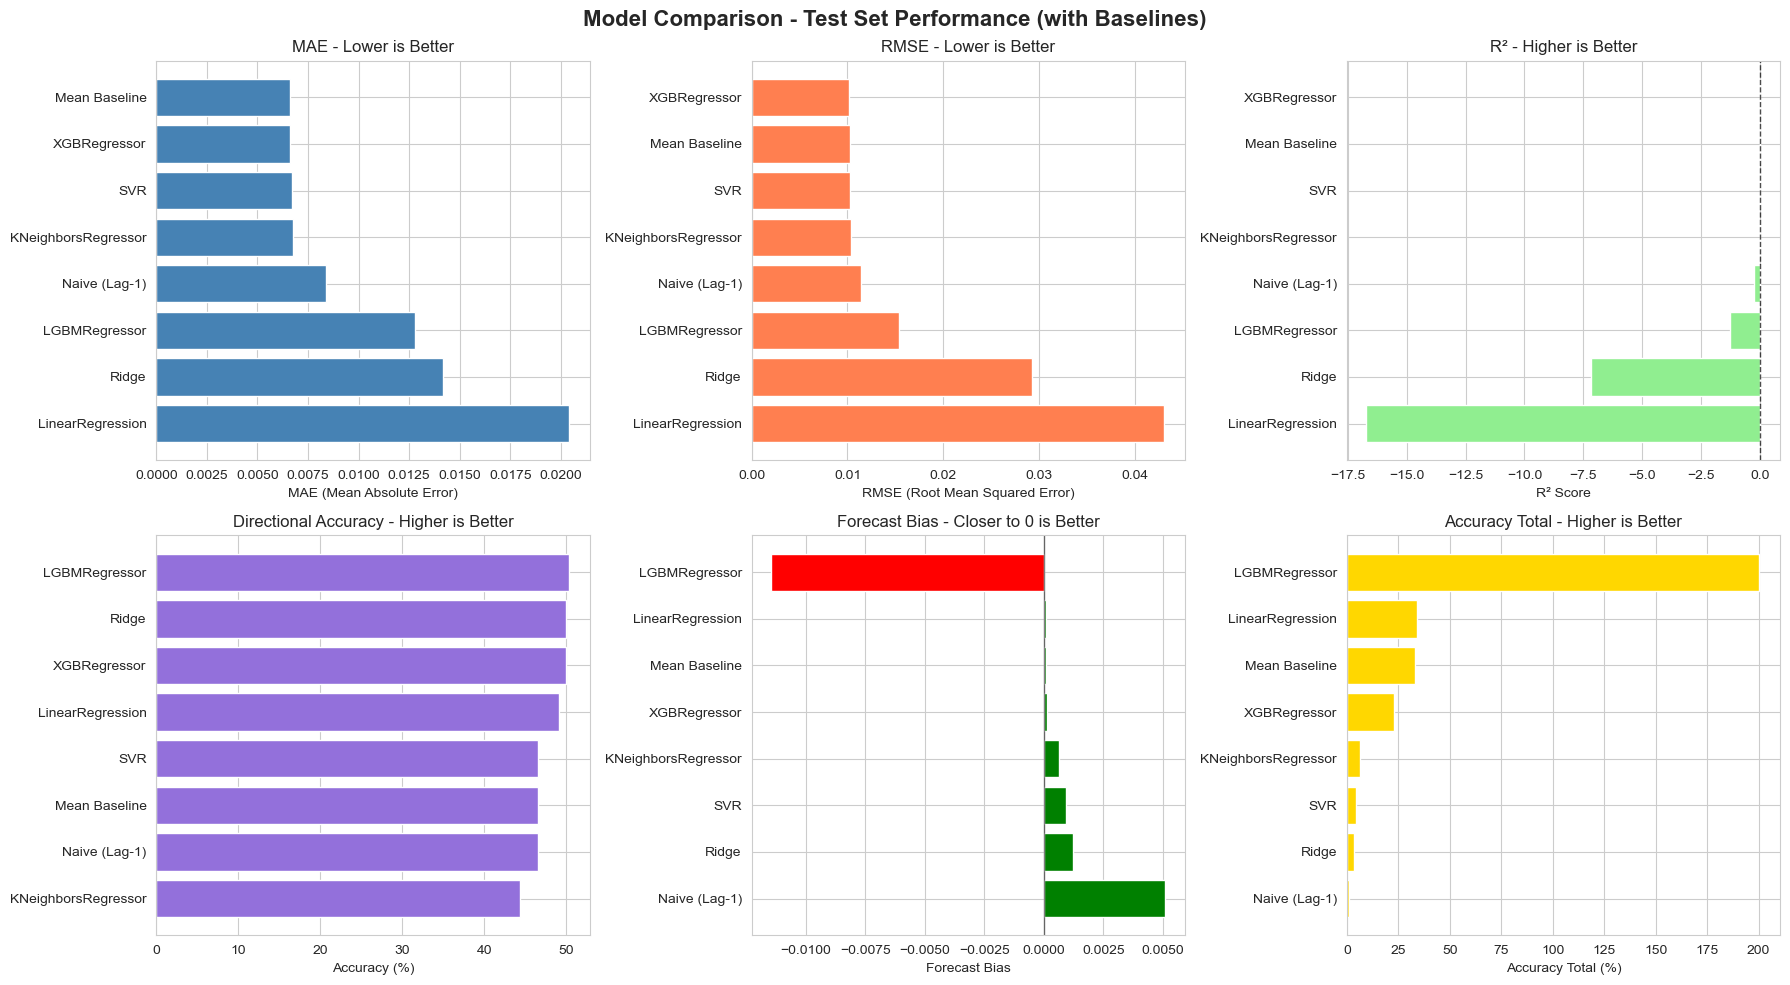

Updated results saved to: ..\results\sklearn_baselines\baseline_comparison_one_step_res_1h.csv


In [ ]:
# Plot Results with Baselines
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Model Comparison - Test Set Performance (with Baselines)", fontsize=16, fontweight='bold')

# MAE
ax = axes[0, 0]
results_df_sorted = results_df.sort_values("MAE")
ax.barh(results_df_sorted["Model"], results_df_sorted["MAE"], color='steelblue')
ax.set_xlabel("MAE (Mean Absolute Error)")
ax.set_title("MAE - Lower is Better")
ax.invert_yaxis()

# RMSE
ax = axes[0, 1]
results_df_sorted = results_df.sort_values("RMSE")
ax.barh(results_df_sorted["Model"], results_df_sorted["RMSE"], color='coral')
ax.set_xlabel("RMSE (Root Mean Squared Error)")
ax.set_title("RMSE - Lower is Better")
ax.invert_yaxis()

# R²
ax = axes[0, 2]
results_df_sorted = results_df.sort_values("R2", ascending=False)
ax.barh(results_df_sorted["Model"], results_df_sorted["R2"], color='lightgreen')
ax.set_xlabel("R² Score")
ax.set_title("R² - Higher is Better")
ax.invert_yaxis()
ax.axvline(x=0, color='black', linestyle='--', linewidth=1, alpha=0.7)

# Directed Accuracy
ax = axes[1, 0]
results_df_sorted = results_df.sort_values("Directed_Accuracy", ascending=False)
ax.barh(results_df_sorted["Model"], results_df_sorted["Directed_Accuracy"] * 100, color='mediumpurple')
ax.set_xlabel("Accuracy (%)")
ax.set_title("Directional Accuracy - Higher is Better")
ax.invert_yaxis()

# Forecast Bias
ax = axes[1, 1]
results_df_sorted = results_df.sort_values("Forecast_Bias")
colors = ['red' if x < 0 else 'green' for x in results_df_sorted["Forecast_Bias"]]
ax.barh(results_df_sorted["Model"], results_df_sorted["Forecast_Bias"], color=colors)
ax.set_xlabel("Forecast Bias")
ax.set_title("Forecast Bias - Closer to 0 is Better")
ax.invert_yaxis()
ax.axvline(x=0, color='black', linestyle='-', linewidth=1, alpha=0.5)

# Accuracy Total
ax = axes[1, 2]
results_df_sorted = results_df.sort_values("Accuracy_Total", ascending=False)
ax.barh(results_df_sorted["Model"], results_df_sorted["Accuracy_Total"], color='gold')
ax.set_xlabel("Accuracy Total (%)")
ax.set_title("Accuracy Total - Higher is Better")
ax.invert_yaxis()

plt.tight_layout()
fig_path = results_dir / "baseline_comparison_one_step_res_1h.png"
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f"Plot saved to: {fig_path}")
plt.show()

# Save updated results
csv_path = results_dir / "baseline_comparison_one_step_res_1h.csv"
results_df.to_csv(csv_path, index=False)
print(f"Updated results saved to: {csv_path}")

In [ ]:
# Train LGBM models für Feature Importance
rf_model = LGBMRegressor(
    random_state=42,
    n_estimators=1200,
    learning_rate=0.02,
    num_leaves=63,
    min_child_samples=10,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.0,
    reg_lambda=0.5,
    objective="regression",
    n_jobs=-1,
    boost_from_average=False
)
rf_model.fit(train_features, _to_1d_target(train_target))

LGBM_importance = pd.DataFrame({
    'feature': train_features.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nLightGBM - Top Features:")
print(LGBM_importance.head(40))


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.087343 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 238214
[LightGBM] [Info] Number of data points in the train set: 2179, number of used features: 936

LightGBM - Top Features:
                        feature  importance
241     ZINC_Vol._rolling_3_std        1067
522     LEAD_High_rolling_3_std         762
385     GOLD_Open_rolling_6_std         727
879   NICKEL_Open_rolling_3_std         724
607            COPPER_Low_lag_1         659
183              ALU_Vol._lag_6         623
491    SILVER_Low_rolling_6_std         474
132             GOLD_Vol._lag_7         467
148              ALU_Vol._lag_4         466
30      ALU_Close_rolling_3_std         455
492           COPPER_Vol._lag_7         428
777     ALU_Close_rolling_6_std         426
891       ALU_Low_rolling_6_std         402
346      ALU_Vol._rolling_3_std         396
467   COPPER_High_rolli

## Reduced Feature Set

In [ ]:
from sklearn.base import clone

feature_importance = LGBM_importance.copy().reset_index(drop=True)
feature_importance["importance_share"] = feature_importance["importance"] / feature_importance["importance"].sum()
feature_importance["cumulative_share"] = feature_importance["importance_share"].cumsum()

min_features = 120
importance_threshold = 0.95
selected_features = feature_importance.loc[
    feature_importance["cumulative_share"] <= importance_threshold,
    "feature"
].tolist()

if len(selected_features) < min_features:
    selected_features = feature_importance.head(min_features)["feature"].tolist()

selected_features = list(dict.fromkeys(selected_features))
print(f"Selected {len(selected_features)} of {train_features.shape[1]} features")
print("Top selected features:")
print(selected_features[:30])

train_features_reduced = train_features[selected_features].copy()
val_features_reduced = val_features[selected_features].copy()
test_features_reduced = test_features[selected_features].copy()

reduced_results = []
reduced_results.extend(
    results_df.loc[results_df["Model"].isin(["Naive (Lag-1)", "Mean Baseline"])].to_dict("records")
)

print("\nTraining ML Models on reduced feature set...")
for model in models:
    reduced_model = clone(model)
    val_score, test_score = trainmodel(
        reduced_model,
        train_features_reduced,
        train_target,
        val_features_reduced,
        val_target,
        test_features_reduced,
        test_target,
    )
    model_name = get_model_name(model)
    print(f"{model_name} - Reduced Test Score: {test_score}")
    reduced_results.append({
        "Model": model_name,
        "MAE": test_score.mae,
        "RMSE": test_score.rmse,
        "MSE": test_score.mse,
        "R2": test_score.r2,
        "SMAPE": test_score.smape,
        "SMAPE_Total": test_score.smape_total,
        "Forecast_Bias": test_score.forecast_bias,
        "Accuracy_Total": test_score.accuracy_total,
        "Directed_Accuracy": test_score.directed_accuracy,
    })

reduced_results_df = pd.DataFrame(reduced_results)
print("\n" + "=" * 80)
print(reduced_results_df.sort_values("MAE").to_string())
print("=" * 80)


Selected 494 of 936 features
Top selected features:
['ZINC_Vol._rolling_3_std', 'LEAD_High_rolling_3_std', 'GOLD_Open_rolling_6_std', 'NICKEL_Open_rolling_3_std', 'COPPER_Low_lag_1', 'ALU_Vol._lag_6', 'SILVER_Low_rolling_6_std', 'GOLD_Vol._lag_7', 'ALU_Vol._lag_4', 'ALU_Close_rolling_3_std', 'COPPER_Vol._lag_7', 'ALU_Close_rolling_6_std', 'ALU_Low_rolling_6_std', 'ALU_Vol._rolling_3_std', 'COPPER_High_rolling_6_min', 'LEAD_Open_rolling_6_std', 'ALU_Low_rolling_12_std', 'NICKEL_Vol._lag_5', 'ALU_Vol._lag_7', 'ALU_Vol._rolling_6_std', 'NICKEL_High_rolling_3_std', 'SILVER_Vol._lag_7', 'NICKEL_Low_rolling_3_std', 'NICKEL_Vol._lag_8', 'ALU_High_rolling_6_std', 'ZINC_Close_rolling_6_std', 'NICKEL_Vol._lag_11', 'LEAD_Vol._lag_5', 'LEAD_Low_rolling_3_std', 'COPPER_Close_rolling_6_std']

Training ML Models on reduced feature set...
SVR - Reduced Test Score: EvaluationResults(mae=0.006666603777183595, rmse=0.010246122917764838, mse=0.00010498303484594583, r2=-0.004502727488657987, smape=np.float

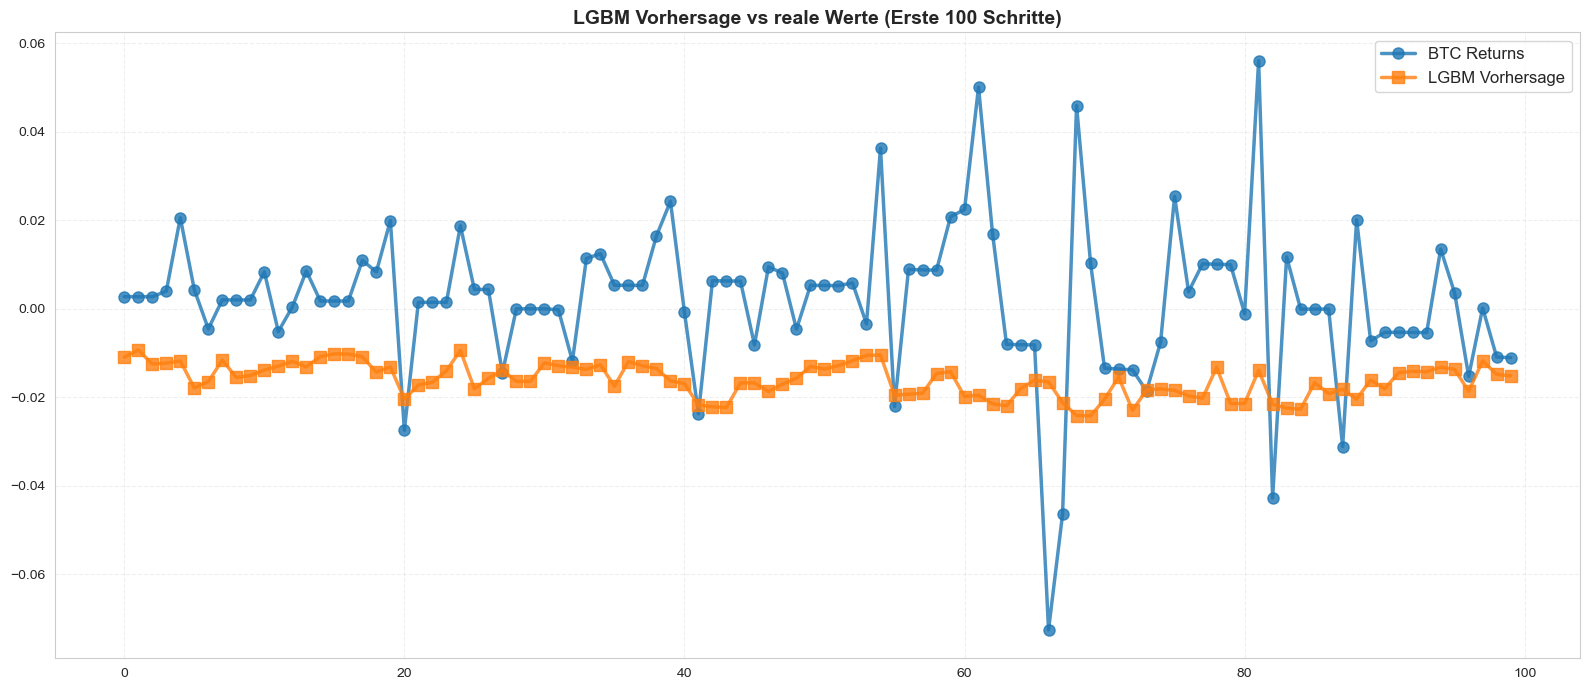

In [ ]:
# LGBM: Zoomed Version - First 100 Data Points
# Create a zoomed-in view of the first 100 time steps for better visibility of individual predictions

zoom_steps = min(100, len(test_comparison))
test_comparison_zoomed = test_comparison.head(zoom_steps)

fig, ax = plt.subplots(figsize=(16, 7))
ax.plot(test_comparison_zoomed['Time'], test_comparison_zoomed['Ground Truth'], 
        label='BTC Returns', linewidth=2.5, marker='o', markersize=8, alpha=0.8, color='#1f77b4')
ax.plot(test_comparison_zoomed['Time'], test_comparison_zoomed['LGBM Predictions'], 
        label='LGBM Vorhersage', linewidth=2.5, marker='s', markersize=8, alpha=0.8, color='#ff7f0e')
ax.set_xlabel('', fontsize=13, fontweight='bold')
ax.set_ylabel('', fontsize=13, fontweight='bold')
ax.set_title(f'LGBM Vorhersage vs reale Werte (Erste {zoom_steps} Schritte)', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=12, loc='best')
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()
